In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('./data/processed/processed_file.csv', encoding='utf-8-sig')

# Первичный осмотр
print(f"📊 Данные: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"📅 Период: {df['Дата заказа'].min()} — {df['Дата заказа'].max()}")
print(f"🏪 Магазины: {df['Магазин'].unique()}")
print(f"📄 Чеков: {df['Файл'].nunique()}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

📊 Данные: 2517 строк, 10 колонок
📅 Период: 2024-11-15 20:42:46 — 2026-05-22 12:15:39
🏪 Магазины: ['edostavka' 'sosedi']
📄 Чеков: 86

Типы данных:
Магазин                   object
Файл                      object
Дата заказа               object
Товар                     object
Количество               float64
Единица                   object
Вес единицы              float64
Цена за единицу (BYN)    float64
Итого (BYN)              float64
Сумма чека (BYN)         float64
dtype: object

Пропуски:
Магазин                    0
Файл                       0
Дата заказа                0
Товар                      0
Количество                 0
Единица                   67
Вес единицы              116
Цена за единицу (BYN)      0
Итого (BYN)                0
Сумма чека (BYN)           0
dtype: int64


In [2]:
# Конвертация даты

df['Дата заказа'] = pd.to_datetime(df['Дата заказа'])

# Извлечение временных признаков
df['Час'] = df['Дата заказа'].dt.hour
df['День недели'] = df['Дата заказа'].dt.dayofweek  # 0=пн, 6=вс
df['День недели_текст'] = df['Дата заказа'].dt.day_name()
df['Месяц'] = df['Дата заказа'].dt.month
df['Год'] = df['Дата заказа'].dt.year
df['Дата (без времени)'] = df['Дата заказа'].dt.date

# Преобразование веса единицы в число
df['Вес единицы'] = pd.to_numeric(df['Вес единицы'], errors='coerce')

# Категоризация товаров
def categorize_product(product_name):
    """
    Расширенная категоризация товаров с отдельными категориями
    """
    product_name = str(product_name).lower()
    
    # 1. Молочные продукты
    milk_keywords = [
        'молоко', 'йогурт', 'творог', 'сливки', 'кефир', 'сметана', 
        'масло сл', 'сыр', 'ряженка', 'простокваша', 'бифидок', 
        'творожок', 'сырок', 'крем сливоч', 'масло крестьянское',
        'напиток к/м', 'эксп', 'teos', 'здравушка', 'беллакт', 
        'слав.традиции', 'баб.крынка', 'chob', 'parmalat', 'нуво'
    ]
    if any(word in product_name for word in milk_keywords):
        return '🥛 Молочные продукты'
    
    # 2. Мясо и птица
    meat_keywords = [
        'фарш', 'сосиски', 'сардельки', 'голень', 'бекон', 'индейка', 
        'курица', 'цыпленок', 'филе', 'петруха', 'колбаса', 'ветчина', 
        'карбонад', 'грудинка', 'рулет', 'вырезка', 'бройлер', 
        'пельмени', 'вареники', 'котлета', 'биток', 'шницель', 
        'буженина', 'сервелат', 'дзержинка', 'римские', 'троицкие',
        'паляндвица', 'мясн орех', 'охотн', 'кабаносы', 'мортаделла',
        'пражская', 'парма', 'мил.экст', 'биробиджан', 'филейный'
    ]
    if any(word in product_name for word in meat_keywords):
        return '🍖 Мясо/птица'
    
    # 3. Фрукты
    fruit_keywords = [
        'яблоко', 'яблоки', 'банан', 'груша', 'клементин', 'мандарин', 'апельсин', 
        'лимон', 'авокадо', 'хурма', 'манго', 'киви', 'ананас', 'гранат',
        'виноград', 'грейпфрут', 'помело', 'нектарин', 'дыня', 'арбуз',
        'фейхоа', 'слива', 'персик', 'абрикос', 'черешня', 'вишня',
        'малина', 'клубника', 'голубика', 'черника', 'клюква', 'брусника',
        'инжир', 'финики'
    ]
    if any(word in product_name for word in fruit_keywords):
        return '🍎 Фрукты'
    
    # 4. Овощи
    vegetable_keywords = [
        'картофель', 'морковь', 'капуста', 'свекла', 'лук', 'редис', 
        'огурец', 'помидор', 'томат', 'перец', 'баклажан', 'кабачок',
        'тыква', 'редька', 'репа', 'чеснок', 'имбирь', 'сельдерей',
        'петрушка', 'укроп', 'салат', 'айсберг', 'шпинат', 'щавель',
        'грибы', 'шампиньоны', 'вешенки', 'брокколи', 'цветная капуста',
        'спаржа', 'артишок', 'батат', 'редис дайкон', 'топинамбур',
        'пастернак', 'хрен', 'рукола', 'кресс-салат'
    ]
    if any(word in product_name for word in vegetable_keywords):
        return '🥬 Овощи'
    
    # 5. Рыба и морепродукты
    seafood_keywords = [
        'рыба', 'сельдь', 'форель', 'минтай', 'окунь', 'семга', 'лосось',
        'треска', 'щука', 'судак', 'лещ', 'карась', 'карп', 'сом',
        'креветка', 'мидии', 'кальмар', 'осьминог', 'краб', 'матиес',
        'икра', 'бремор', 'морепродукты', 'анчоусы', 'килька', 'шпроты'
    ]
    if any(word in product_name for word in seafood_keywords):
        return '🐟 Рыба/морепродукты'
    
    # 6. СЛАДОСТИ (выделяем отдельно)
    sweets_keywords = [
        'печенье', 'мороженное', 'вафли', 'пряники', 'кекс', 'пирожное', 'торт', 
        'зефир', 'мармелад', 'конфеты', 'шоколад', 'батончики', 
        'вафельный бат', 'маршмеллоу', 'глаз. с арахисом', 'карамель',
        'леденец', 'ирис', 'нуга', 'халва', 'козинак', 'драже',
        'суфле', 'крем', 'десерт', 'чокопай', 'эклер', 'профитроли',
        'слойка', 'сладкая идея', 'витьба by', 'milka', 'спартак', 'merci'
    ]
    if any(word in product_name for word in sweets_keywords):
        return '🍰 Сладости'
    
    # 7. КАШИ И ХЛОПЬЯ (выделяем отдельно)
    cereals_keywords = [
        'каша', 'хлопья', 'готовый зав', 'овсянка', 'геркулес', 'мюсли',
        'крупа', 'рис', 'гречка', 'манка', 'пшено', 'перловка', 'ячка',
        'чечевица', 'горох', 'фасоль', 'киноа', 'булгур', 'кускус'
    ]
    if any(word in product_name for word in cereals_keywords):
        return '🥣 Каши/крупы'
    
    # 8. ХЛЕБ И ХЛЕБОБУЛОЧНЫЕ ИЗДЕЛИЯ (выделяем отдельно)
    bread_keywords = [
        'хлеб', 'батон', 'булка', 'лаваш', 'багет', 'бублик', 'сушки', 
        'баранки', 'рогалик', 'плетенка', 'кирпичик', 'тостовый',
        'чиабатта', 'пита', 'тортилья', 'лепешка', 'сочень', 'калач',
        'кулич', 'пасха', 'кекс домашний'
    ]
    if any(word in product_name for word in bread_keywords):
        return '🍞 Хлеб/выпечка'
    
    # 9. МАКАРОННЫЕ ИЗДЕЛИЯ (отдельно)
    pasta_keywords = [
        'макароны', 'мак.изд', 'паста', 'спагетти', 'вермишель', 
        'лапша', 'рожки', 'перья', 'ракушки', 'спиральки', 'филини',
        'вермичелли', 'маккерони', 'стеллине', 'ризони', 'фузили',
        'пенне', 'барра', 'zara', 'barilla'
    ]
    if any(word in product_name for word in pasta_keywords):
        return '🍝 Макароны'
    
    # 10. НАПИТКИ (кофе, чай, соки и т.д.)
    beverages_keywords = [
        'кофе', 'чай', 'какао', 'сок', 'нектар', 'морс', 'компот', 
        'квас', 'лимонад', 'газировка', 'вода', 'энергетик', 'кола', 
        'спрайт', 'фанта', 'пиво', 'вино', 'шампанское', 'коньяк', 'водка',
        'jardin', 'lavazza', 'illy', 'жокей', 'dallmayr', 'greenfield'
    ]
    if any(word in product_name for word in beverages_keywords):
        return '☕ Напитки'
    
    # 11. ЯЙЦА (отдельно)
    if any(word in product_name for word in ['яйцо', 'яйца']):
        return '🥚 Яйца'
    
    # 12. Детские товары
    baby_keywords = [
        'подгузник', 'памперс', 'трусики', 'пеленка', 'салфетки влаж',
        'бутылочка', 'соска', 'пустышка', 'пюре дет', 'каша дет',
        'смесь молочная', 'непоседа', 'топтышка', 'беллакт дет',
        'watashi', 'senso', 'tanoshi', 'tokisan', 'miu', 'pampers',
        'yumiko', 'омегга', 'деревенское яйцо', 'златко', 'молодец.люкс'
    ]
    if any(word in product_name for word in baby_keywords):
        return '👶 Детские товары'
    
    # 13. Бытовая химия и гигиена
    household_keywords = [
        'бумага туал', 'салфетки', 'полотенце', 'мыло', 'шампунь',
        'гель душ', 'зубная паста', 'щетка', 'прокладка', 'тампон',
        'крем для рук', 'лосьон', 'стиральный порошок', 'кондиционер',
        'средство для мытья', 'чистящее', 'ромакс', 'вела', 'папиа',
        'зипто', 'соффион', 'фэмилиа', 'вейро', 'люксориа', 'арома'
    ]
    if any(word in product_name for word in household_keywords):
        return '🧹 Бытовая химия'
    
    # 14. БАКАЛЕЯ (остальное: соусы, специи, масло, консервы и т.д.)
    grocery_keywords = [
        'мука', 'дрожжи', 'разрыхлитель', 'соль', 'сахар', 'крахмал',
        'кетчуп', 'майонез', 'соус', 'уксус', 'масло раст', 'специи', 
        'приправы', 'варенье', 'джем', 'мед', 'сгущенка', 'конс.мол',
        'сгущ', 'горошек конс', 'кукуруза конс', 'фасоль конс', 
        'оливки', 'маслины', 'консервы', 'паштет', 'тушенка',
        'суп', 'бульон', 'кисель', 'желе', 'пудинг', 'хлебцы', 'сухари',
        'чипсы', 'попкорн', 'снеки', 'орехи', 'семечки', 'суши',
        'эколайн', 'фермер', 'стол.мельница', 'др.бейкерс', 'пряный дом',
        'махеев', 'heinz', 'mikado', 'green ray', 'bonfesto', 'кэнапс'
    ]
    if any(word in product_name for word in grocery_keywords):
        return '🛒 Прочая бакалея'
    
    # 16. Если ничего не подошло
    return product_name

df['Категория'] = df['Товар'].apply(categorize_product)

# -------------------------------------------------------------

# Нормализация количества для весовых товаров (кг/л в граммы/мл)
# 1. По умолчанию копируем исходное количество
df['Вес_норм'] = df['Вес единицы']

# 2. Быстро умножаем на 1000 только там, где единица 'кг' или 'л'
mask = df['Единица'].isin(['кг', 'л'])
df.loc[mask, 'Вес_норм'] = df.loc[mask, 'Вес_норм'] * 1000

# -------------------------------------------------------------

# Агрегация по чеку
cheque_stats = df.groupby('Файл').agg({
    'Итого (BYN)': 'sum',
    'Дата заказа': 'first',
    'Магазин': 'first',
    'Час': 'first',
}).reset_index()
cheque_stats.columns = ['Файл', 'Сумма чека (расч)', 'Дата заказа', 'Магазин', 'Час']
# cheque_stats['Час'] = cheque_stats['Дата заказа'].dt.hour
# cheque_stats['Час'] = pd.to_datetime(cheque_stats['Дата заказа']).dt.hour
cheque_stats['День недели_текст'] = pd.to_datetime(cheque_stats['Дата заказа']).dt.day_name()


print("✅ Предобработка завершена")


# res = cheque_stats[cheque_stats['Файл'] == 'Cheque-1501288055.pdf']
# res


✅ Предобработка завершена


In [3]:
df.sample(n=20)[['Товар', 'Категория']]

,Товар,Категория
716,"Лапша б/п""ДОШ.ЧАН РАМЕН""(припр/гов)120г",🍝 Макароны
334,"Форель охл. (п/с/г,2-3)2.3 -2.4кг",🐟 Рыба/морепродукты
179,Грейпфрут красный 1кг,🍎 Фрукты
879,"Масло сл/сл""СЛАВ.ТРАДИЦИИ""82.5%,180г",🥛 Молочные продукты
2381,КРУПА ГРЕЧНЕВАЯ УМНЫЙ ВЫБОР ЯДРИЦА 700Г,🥣 Каши/крупы
958,"Сметана ""ЗДРАВУШКА""24% (пленка)400г",🥛 Молочные продукты
582,Тушенка говяжья 325г,🛒 Прочая бакалея
616,"Пюре""ТОПТЫШКА""(яблоко,груша,перcик) 190г",🍎 Фрукты
2425,П/Ф ЦЫПЛЕНОК ГОЛЕНЬ ОХЛ.ЛОТ.750Г,🍖 Мясо/птица
26,Мандарин 1 кг,🍎 Фрукты


In [4]:
print("="*60)
print("📊 БАЗОВАЯ СТАТИСТИКА")
print("="*60)

print(f"🛒 Средний чек: {cheque_stats['Сумма чека (расч)'].mean():.2f} BYN")
print(f"📦 Среднее кол-во товаров в чеке: {df.groupby('Файл').size().mean():.1f} шт")

📊 БАЗОВАЯ СТАТИСТИКА
🛒 Средний чек: 233.88 BYN
📦 Среднее кол-во товаров в чеке: 29.3 шт



🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л             572.85 BYN
 2. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                    450.54 BYN
 3. Масло сл/сл"СЛАВ.ТРАДИЦИИ"82.5%,180г                 348.65 BYN
 4. Творог"ЗДРАВУШКА"9%,200г                             342.41 BYN
 5. Фарш индейка-курица (зам.) 1/500                     301.21 BYN
 6. Сардельки"РИМСКИЕ"(в/с,цб,в/у)390г                   215.43 BYN
 7. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г           201.01 BYN
 8. Банан 1кг                                            197.38 BYN
 9. Йогурт"TEOS"2%(греческ,черника)250г                  183.35 BYN
10. Форель охл. (п/с/г,3-4) 3.4-3.6 кг                   174.25 BYN

🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК
 1. Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л            48 раз(а)
 2. Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л                   45 раз(а)
 3. [М] СЫР БРЕСТ-ЛИТОВСК МААСДАМ 45% ФАС.200Г          37 раз(а)
 4. Банан 1кг                                     

/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 129371 (\N{GLASS OF MILK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 127830 (\N{MEAT ON BONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 129388 (\N{LEAFY GREEN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 127856 (\N{SHORTCAKE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 128031 (\N{FISH}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/742023802.py:35: UserWarning: Glyph 128118 (\N{BABY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_18125/7420238

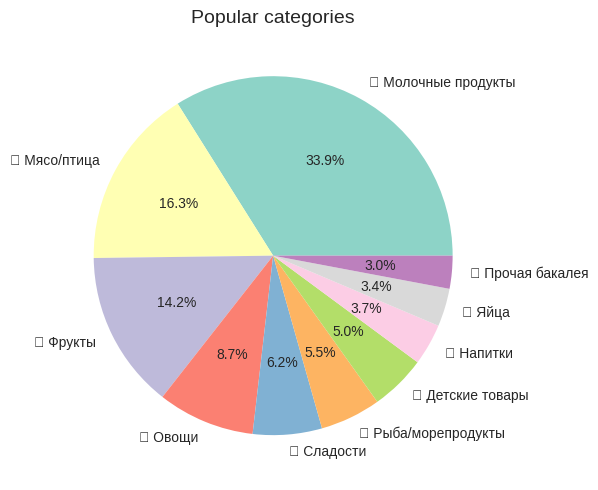

In [5]:
# Топ-10 товаров по сумме
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО СУММЕ ПОКУПОК")
print("="*60)
top_products = df.groupby('Товар')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
for i, (product, total) in enumerate(top_products.items(), 1):
    print(f"{i:2}. {product[:50]:50} {total:8.2f} BYN")

# help(df['Товар'].value_counts)

# Топ-10 товаров по частоте
print("\n" + "="*60)
print("🏆 ТОП-10 ТОВАРОВ ПО ЧАСТОТЕ ПОКУПОК")
print("="*60)
top_frequent = df['Товар'].value_counts().head(10)
for i, (product, count) in enumerate(top_frequent.items(), 1):
    print(f"{i:2}. {product[:50]:50} {count:3} раз(а)")

# По категориям
print("\n" + "="*60)
print("📂 ПОПУЛЯРНОСТЬ КАТЕГОРИЙ")
print("="*60)
category_sum = df.groupby('Категория')['Итого (BYN)'].sum().sort_values(ascending=False).head(10)
category_count = df['Категория'].value_counts()

for cat in category_sum.index:
    print(f"{cat:12} | Сумма: {category_sum[cat]:7.2f} BYN | Кол-во: {category_count[cat]:3} шт | Доля: {category_sum[cat]/df['Итого (BYN)'].sum()*100:.1f}%")


colors = plt.cm.Set3(range(len(category_count)))

plt.figure(figsize=(12, 5))
plt.pie(category_sum, labels=category_sum.index, autopct='%1.1f%%', colors=colors)
plt.title('Popular categories', fontsize=14)
plt.tight_layout()
plt.show()






⏰ АНАЛИЗ ПО ЧАСАМ

📊 По часам:
     Сумма_покупок  Средняя_цена_товара  Кол-во_чеков
Час                                                  
6           952.47                10.03             3
7           953.23                 8.99             3
8          1269.45                 9.27             4
9           540.82                 4.47             3
10          380.16                 4.94             3
11         1341.59                 5.73            10
12          307.63                 4.16             3
15          328.87                 4.57             3
17          464.68                 8.15             2
18         1577.80                 8.26             7
19         3930.53                 8.75            15
20          921.69                 7.49             4
21         2582.77                 9.57             9
22         1459.80                 8.96             5
23         3101.99                 8.91            12


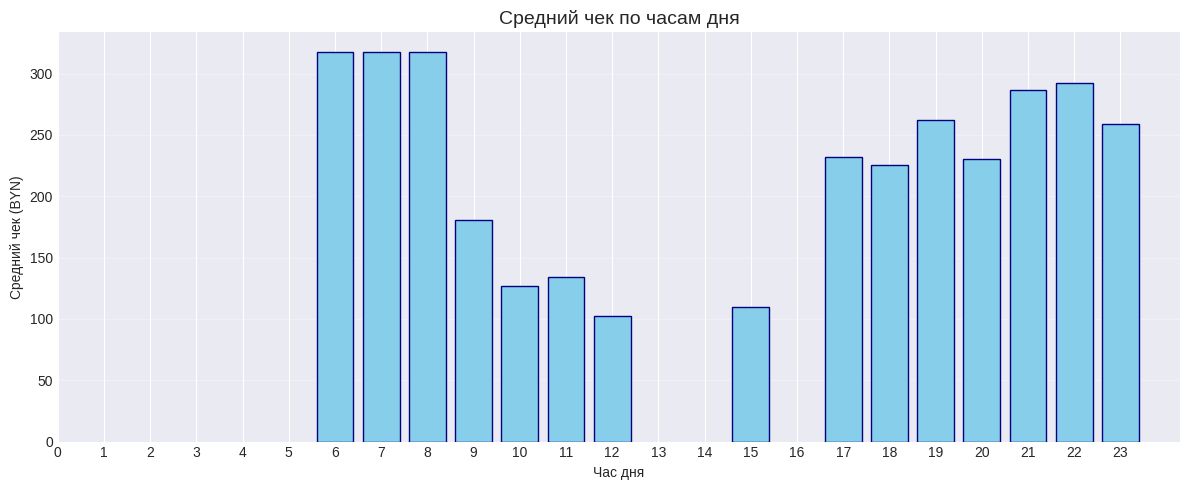


📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ
Monday     | Чеков: 12 | Общая сумма: 2248.55 BYN | Средний чек: 187.38 BYN
Tuesday    | Чеков: 15 | Общая сумма: 3870.94 BYN | Средний чек: 258.06 BYN
Wednesday  | Чеков: 11 | Общая сумма: 2740.05 BYN | Средний чек: 249.10 BYN
Thursday   | Чеков: 12 | Общая сумма: 2915.72 BYN | Средний чек: 242.98 BYN
Friday     | Чеков: 14 | Общая сумма: 3345.21 BYN | Средний чек: 238.94 BYN
Saturday   | Чеков: 14 | Общая сумма: 3163.31 BYN | Средний чек: 225.95 BYN
Sunday     | Чеков:  8 | Общая сумма: 1829.70 BYN | Средний чек: 228.71 BYN


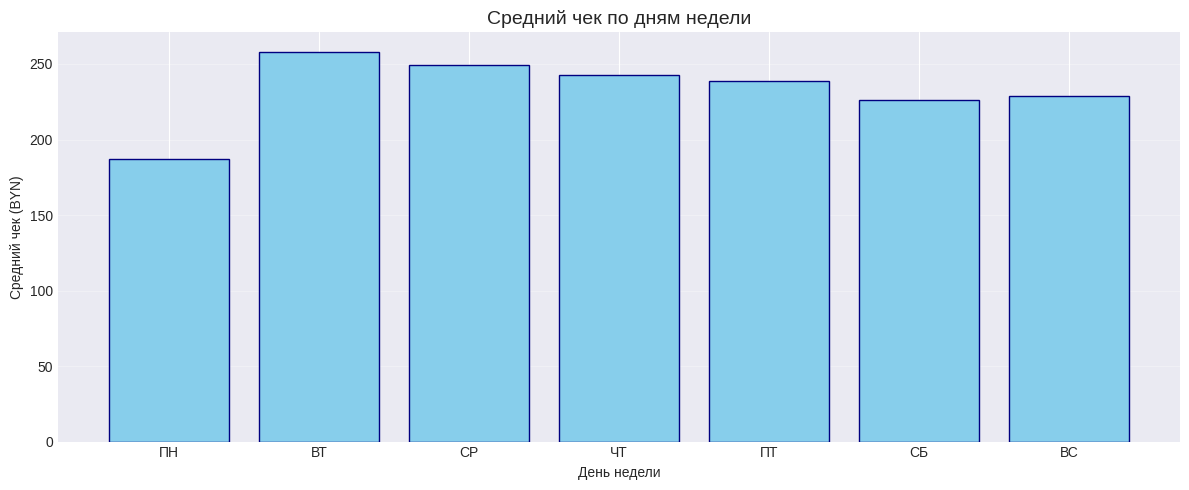

In [6]:
# По часам
print("\n" + "="*60)
print("⏰ АНАЛИЗ ПО ЧАСАМ")
print("="*60)

hourly_stats = df.groupby('Час').agg({
    'Итого (BYN)': ['sum', 'mean'],
    'Файл': 'nunique'
}).round(2)
hourly_stats.columns = ['Сумма_покупок', 'Средняя_цена_товара', 'Кол-во_чеков']

print("\n📊 По часам:")
print(hourly_stats)

# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('Час')['Сумма чека (расч)'].mean()
plt.bar(hourly_cheque.index, hourly_cheque.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по часам дня', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# По дням недели
print("\n" + "="*60)
print("📅 АНАЛИЗ ПО ДНЯМ НЕДЕЛИ")
print("="*60)


days_order_ru = ['ПН', 'ВТ', 'СР', 'ЧТ', 'ПТ', 'СБ', 'ВС']
days_map = {
    'Monday': 'ПН', 'Tuesday': 'ВТ', 'Wednesday': 'СР',
    'Thursday': 'ЧТ', 'Friday': 'ПТ', 'Saturday': 'СБ', 'Sunday': 'ВС'
}

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('День недели_текст').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique'
}).reindex(days_order)

for day in days_order:
    if day in daily_stats.index:
        avg_cheque = daily_stats.loc[day, 'Итого (BYN)'] / daily_stats.loc[day, 'Файл']
        print(f"{day:10} | Чеков: {daily_stats.loc[day, 'Файл']:2} | Общая сумма: {daily_stats.loc[day, 'Итого (BYN)']:7.2f} BYN | Средний чек: {avg_cheque:.2f} BYN")


# График: средний чек по часам
plt.figure(figsize=(12, 5))
hourly_cheque = cheque_stats.groupby('День недели_текст')['Сумма чека (расч)'].mean()
hourly_cheque_sorted = hourly_cheque.reindex(days_order).rename(days_map)

plt.bar(hourly_cheque_sorted.index, hourly_cheque_sorted.values, color='skyblue', edgecolor='navy')
plt.title('Средний чек по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(0, 7))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()        


🌸 СЕЗОННЫЙ АНАЛИЗ
12
       Итого (BYN)  Файл  Товар
Месяц                          
1          2155.75     8    255
2          1366.23     5    153
3          1926.22    12    282
4          2529.41    13    366
5          2286.47    13    377
6          1173.46     4    140
7          1072.10     4    114
8           951.90     4    109
9          1116.38     4    116
10         1198.82     4    110
11         1807.32     6    201
12         2529.42     9    294


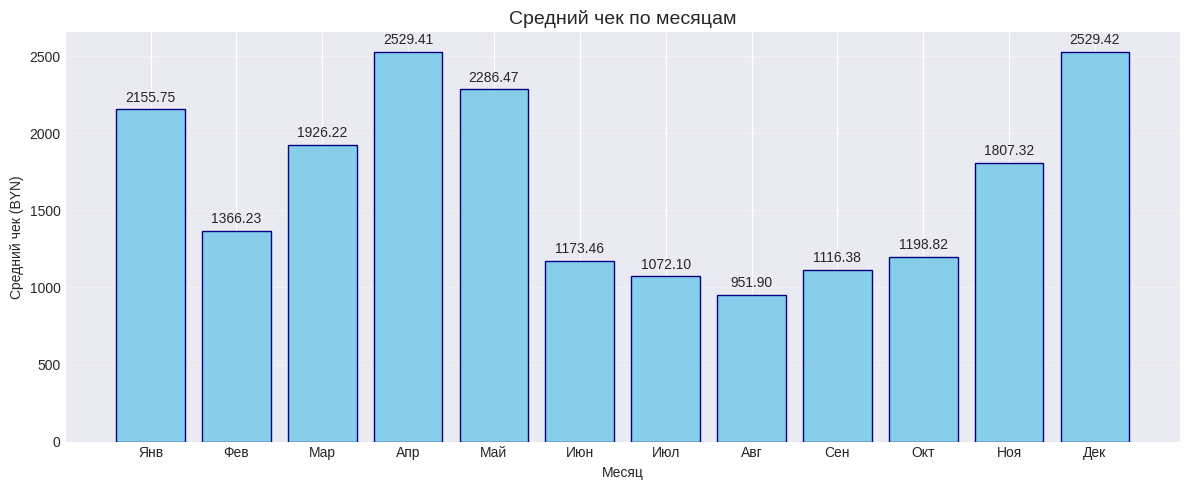

Янв  | Сумма: 2155.75 BYN | Чеков:  8 | Товаров: 255
Фев  | Сумма: 1366.23 BYN | Чеков:  5 | Товаров: 153
Мар  | Сумма: 1926.22 BYN | Чеков: 12 | Товаров: 282
Апр  | Сумма: 2529.41 BYN | Чеков: 13 | Товаров: 366
Май  | Сумма: 2286.47 BYN | Чеков: 13 | Товаров: 377
Июн  | Сумма: 1173.46 BYN | Чеков:  4 | Товаров: 140
Июл  | Сумма: 1072.10 BYN | Чеков:  4 | Товаров: 114
Авг  | Сумма:  951.90 BYN | Чеков:  4 | Товаров: 109
Сен  | Сумма: 1116.38 BYN | Чеков:  4 | Товаров: 116
Окт  | Сумма: 1198.82 BYN | Чеков:  4 | Товаров: 110
Ноя  | Сумма: 1807.32 BYN | Чеков:  6 | Товаров: 201
Дек  | Сумма: 2529.42 BYN | Чеков:  9 | Товаров: 294


In [7]:
print("\n" + "="*60)
print("🌸 СЕЗОННЫЙ АНАЛИЗ")
print("="*60)

# Месячная динамика
monthly = df.groupby('Месяц').agg({
    'Итого (BYN)': 'sum',
    'Файл': 'nunique',
    'Товар': 'count'
})

print(len(monthly))
print(monthly.head(n=20))

months_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

plt.figure(figsize=(12, 5))
plt.bar(monthly.index, monthly['Итого (BYN)'], color='skyblue', edgecolor='navy')
plt.title('Средний чек по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек (BYN)')
plt.xticks(range(1, len(monthly)+1), months_names)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Добавляем значения на столбцы
for i, value in enumerate(monthly['Итого (BYN)']):
    plt.text(i + 1, value + 50, f'{value:.2f}', ha='center', fontsize=10)
plt.show()


for month in monthly.index:
    if month <= len(months_names):
        print(f"{months_names[month-1]:4} | Сумма: {monthly.loc[month, 'Итого (BYN)']:7.2f} BYN | Чеков: {monthly.loc[month, 'Файл']:2} | Товаров: {monthly.loc[month, 'Товар']:2}")



# Сезонные товары (появляются только в определённые месяцы)
# print("\n🍓 ПОТЕНЦИАЛЬНО СЕЗОННЫЕ ТОВАРЫ:")
# seasonal_candidates = ['клементин', 'грейпфрут', 'мандарин', 'арбуз', 'клубника']
# for candidate in seasonal_candidates:
#     mask = df['Товар'].str.lower().str.contains(candidate, na=False)
#     if mask.any():
#         months_found = df[mask]['Месяц'].unique()
#         print(f"   {candidate}: встречается в месяцах {sorted(months_found)}")

In [8]:
print("\n" + "="*60)
print("🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)")
print("="*60)

total_cheques = df['Файл'].nunique()
product_frequency = df.groupby('Товар')['Файл'].nunique().sort_values(ascending=False)
constant_products = product_frequency[product_frequency / total_cheques > 0.4]

# print("\n" + "="*60)
# print(product_frequency)
# print("="*60)
# product_frequency = df.groupby('Товар')['Файл'].nunique().sort_values(ascending=False).reset_index().set_index('Товар')
# print("\n" + "="*60)
# print(product_frequency)
# print("="*60)
# print("\n" + "="*60)
# print(product_frequency.squeeze())
# print("="*60)
# product_frequency = product_frequency.squeeze()
# constant_products = product_frequency[product_frequency / total_cheques > 0.4]


for product, freq in constant_products.head(10).items():
    percentage = (freq / total_cheques) * 100
    print(f"   {product[:45]:45} | {percentage:.0f}% чеков ({freq}/{total_cheques})")


🔄 ПОСТОЯННЫЕ ПОКУПКИ (в >40% чеков)
   Молоко"ЗДРАВУШКА"3.4- 6%(паст,ПЭТ)0.93 л      | 56% чеков (48/86)
   Молоко"ЗДРАВУШКА"3.2%(стер,ТБА)1л             | 52% чеков (45/86)
